In [1]:
#!/usr/bin/env python
# coding: utf-8

# # COVID-19 Impact on Economic Indicators: Data Analysis Project
# 
# This notebook analyzes the relationship between COVID-19 metrics and economic indicators across countries.
# 
# **Datasets:**
# 1. COVID-19 data from Johns Hopkins CSSE
# 2. World Bank economic indicators

# ## 1. Data Importation & Integration

# ### Import necessary libraries
# Import data manipulation, visualization, and statistical analysis libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings

# Configure plotting and display settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ### Download and Import COVID-19 Data
# Access global COVID-19 time series data from Johns Hopkins CSSE GitHub repository

# Download COVID-19 confirmed cases data
url_confirmed = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv"
covid_confirmed = pd.read_csv(url_confirmed)

# Download COVID-19 deaths data
url_deaths = "https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv"
covid_deaths = pd.read_csv(url_deaths)

# Check the dimensions of the dataset to understand its structure
print("COVID-19 Confirmed Cases Dataset Shape:", covid_confirmed.shape)
covid_confirmed.head()

# ### Download and Import Economic Indicators Data
# Create a dataframe with key economic indicators for major countries (GDP growth, unemployment, inflation)
# This simulates data that would typically be retrieved from World Bank API in a production scenario

# Sample economic data for 14 major economies
economic_data = pd.DataFrame({
    'Country': [
        'United States', 'United Kingdom', 'Germany', 'France', 'Italy', 'Spain', 'Japan', 
        'Canada', 'China', 'India', 'Brazil', 'Russia', 'South Korea', 'Australia'
    ],
    'ISO_Code': [
        'US', 'GB', 'DE', 'FR', 'IT', 'ES', 'JP', 
        'CA', 'CN', 'IN', 'BR', 'RU', 'KR', 'AU'
    ],
    'GDP_Growth_2019': [
        2.3, 1.4, 0.6, 1.5, 0.3, 2.0, 0.3, 
        1.9, 6.0, 4.0, 1.1, 2.0, 2.0, 1.8
    ],
    'GDP_Growth_2020': [
        -3.5, -9.8, -4.9, -8.1, -8.9, -10.8, -4.8, 
        -5.3, 2.3, -7.3, -4.1, -3.0, -0.9, -2.4
    ],
    'GDP_Growth_2021': [
        5.7, 7.4, 2.9, 6.8, 6.6, 5.1, 1.6, 
        4.5, 8.1, 8.7, 4.6, 4.7, 4.0, 3.8
    ],
    'Unemployment_2019': [
        3.7, 3.8, 3.1, 8.4, 9.9, 14.1, 2.4, 
        5.7, 3.6, 5.3, 11.9, 4.6, 3.8, 5.2
    ],
    'Unemployment_2020': [
        8.1, 4.5, 3.8, 8.0, 9.3, 15.5, 2.8, 
        9.5, 4.2, 7.1, 13.5, 5.8, 4.0, 6.5
    ],
    'Unemployment_2021': [
        5.4, 4.5, 3.6, 7.9, 9.5, 14.8, 2.8, 
        7.5, 4.0, 5.6, 13.2, 4.8, 3.7, 5.1
    ],
    'Inflation_2019': [
        1.8, 1.8, 1.4, 1.3, 0.6, 0.7, 0.5, 
        1.9, 2.9, 4.8, 3.7, 4.5, 0.4, 1.6
    ], 
    'Inflation_2020': [
        1.2, 0.9, 0.4, 0.5, -0.1, -0.3, 0.0, 
        0.7, 2.5, 6.2, 3.2, 3.4, 0.5, 0.9
    ],
    'Inflation_2021': [
        4.7, 2.6, 3.2, 2.1, 1.9, 3.0, -0.2, 
        3.4, 0.9, 5.1, 8.3, 6.7, 2.5, 2.8
    ],
    'Population_Million': [
        329.5, 67.1, 83.2, 67.4, 60.3, 47.4, 125.8, 
        38.0, 1407.7, 1366.4, 212.6, 145.9, 51.3, 25.7
    ],
    'Health_Expenditure_GDP_Percent': [
        17.0, 10.2, 11.7, 11.1, 8.7, 9.1, 10.7, 
        10.8, 5.2, 3.5, 9.5, 5.3, 8.2, 9.3
    ],
    'Hospital_Beds_Per_1000': [
        2.9, 2.5, 8.0, 5.9, 3.2, 3.0, 13.0, 
        2.5, 4.3, 0.5, 2.2, 8.0, 12.3, 3.8
    ]
})

economic_data.head()

# ### Data Preprocessing for COVID-19 Data
# Transform wide-format COVID-19 data to long format for time series analysis

# Function to reshape COVID data from wide to long format (pivot date columns to rows)
def preprocess_covid_data(df, metric_name):
    # Melt the dataframe to convert date columns to rows
    id_vars = ['Province/State', 'Country/Region', 'Lat', 'Long']
    df_long = df.melt(id_vars=id_vars, var_name='Date', value_name=metric_name)
    
    # Convert Date to datetime for proper time series handling
    df_long['Date'] = pd.to_datetime(df_long['Date'])
    
    # Group by Country/Region and Date to aggregate data (combine provinces/states)
    grouped = df_long.groupby(['Country/Region', 'Date'])[metric_name].sum().reset_index()
    
    return grouped

# Process confirmed cases and death data separately
covid_confirmed_long = preprocess_covid_data(covid_confirmed, 'Confirmed')
covid_deaths_long = preprocess_covid_data(covid_deaths, 'Deaths')

# Merge confirmed cases and deaths data on country and date
covid_data = pd.merge(covid_confirmed_long, covid_deaths_long, on=['Country/Region', 'Date'])

# Calculate daily new cases and new deaths (first differences)
covid_data = covid_data.sort_values(['Country/Region', 'Date'])
covid_data['New_Cases'] = covid_data.groupby('Country/Region')['Confirmed'].diff().fillna(0)
covid_data['New_Deaths'] = covid_data.groupby('Country/Region')['Deaths'].diff().fillna(0)
# Display the processed COVID data
covid_data.head()

# ### Merge COVID-19 Data with Economic Indicators
# Integrate COVID-19 metrics with economic data for cross-analysis

# Create mapping dictionary to standardize country names between datasets
country_mapping = {
    'US': 'United States',
    'United Kingdom': 'United Kingdom',
    'Germany': 'Germany',
    'France': 'France',
    'Italy': 'Italy',
    'Spain': 'Spain',
    'Japan': 'Japan',
    'Canada': 'Canada',
    'China': 'China',
    'India': 'India',
    'Brazil': 'Brazil',
    'Russia': 'Russia',
    'Korea, South': 'South Korea',
    'Australia': 'Australia'
}

# Filter COVID data for countries in our economic dataset
covid_data_filtered = covid_data[covid_data['Country/Region'].isin(country_mapping.keys())].copy()

# Map COVID data country names to match economic data naming convention
covid_data_filtered['Country'] = covid_data_filtered['Country/Region'].map(lambda x: country_mapping.get(x, x))

# Focus on 2020-2021 period, the main COVID impact years
covid_data_filtered = covid_data_filtered[(covid_data_filtered['Date'] >= '2020-01-01') &
                                         (covid_data_filtered['Date'] <= '2021-12-31')]

# Aggregate COVID metrics by country for joining with economic data
covid_metrics = covid_data_filtered.groupby('Country').agg({
    'Confirmed': 'max',  # Total confirmed cases by end of period
    'Deaths': 'max',     # Total deaths by end of period
    'New_Cases': 'mean', # Average daily new cases
    'New_Deaths': 'mean' # Average daily new deaths
}).reset_index()

# Join COVID data with economic indicators
merged_data = pd.merge(covid_metrics, economic_data, on='Country')

# Calculate per-capita metrics using population data
merged_data['Cases_Per_Million'] = merged_data['Confirmed'] / merged_data['Population_Million']
merged_data['Deaths_Per_Million'] = merged_data['Deaths'] / merged_data['Population_Million']

# Display the integrated dataset containing both COVID and economic variables
print("Merged Dataset Shape:", merged_data.shape)
merged_data.head()

COVID-19 Confirmed Cases Dataset Shape: (289, 1147)
Merged Dataset Shape: (14, 20)


,Country,Confirmed,Deaths,New_Cases,New_Deaths,ISO_Code,GDP_Growth_2019,GDP_Growth_2020,GDP_Growth_2021,Unemployment_2019,Unemployment_2020,Unemployment_2021,Inflation_2019,Inflation_2020,Inflation_2021,Population_Million,Health_Expenditure_GDP_Percent,Hospital_Beds_Per_1000,Cases_Per_Million,Deaths_Per_Million
0,Australia,425496,2253,599.290141,3.173239,AU,1.8,-2.4,3.8,5.2,6.5,5.1,1.6,0.9,2.8,25.7,9.3,3.8,16556.264591,87.665370
1,Brazil,22291839,619334,31396.956338,872.301408,BR,1.1,-4.1,4.6,11.9,13.5,13.2,3.7,3.2,8.3,212.6,9.5,2.2,104853.428975,2913.142051
2,Canada,2223735,30320,3132.021127,42.704225,CA,1.9,-5.3,4.5,5.7,9.5,7.5,1.9,0.7,3.4,38.0,10.8,2.5,58519.342105,797.894737
3,China,127896,5103,179.363380,7.163380,CN,6.0,2.3,8.1,3.6,4.2,4.0,2.9,2.5,0.9,1407.7,5.2,4.3,90.854585,3.625062
4,France,10077783,124729,14194.060563,175.674648,FR,1.5,-8.1,6.8,8.4,8.0,7.9,1.3,0.5,2.1,67.4,11.1,5.9,149522.002967,1850.578635


In [2]:
# ## 2. Handling Missing Data & Outliers

# ### Check for Missing Values
# Verify data completeness in both datasets

# Check for missing values in the merged dataset
missing_values = merged_data.isnull().sum()
print("Missing Values in the Merged Dataset:")
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values found!")
# Check for missing values in COVID time series data
covid_missing = covid_data_filtered.isnull().sum()
print("\nMissing Values in COVID Time Series Data:")
print(covid_missing[covid_missing > 0] if any(covid_missing > 0) else "No missing values found!")

# ### Detect and Visualize Outliers
# Identify countries with extreme values that might need special consideration

# Define a function to detect outliers using the Interquartile Range (IQR) method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check for outliers in key metrics of interest
columns_to_check = ['Cases_Per_Million', 'Deaths_Per_Million', 'GDP_Growth_2020', 'Unemployment_2020']

for column in columns_to_check:
    outliers, lower, upper = detect_outliers(merged_data, column)
    if len(outliers) > 0:
        print(f"\nOutliers in {column}:")
        print(f"Bounds: Lower = {lower:.2f}, Upper = {upper:.2f}")
        print(outliers[['Country', column]])

        # Visualize outliers with boxplots
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=merged_data[column])
        plt.title(f'Boxplot of {column} with Outliers')
        plt.tight_layout()
        plt.show()

# ### Handle Missing Values and Outliers
# Process outliers without removing them as they represent valid country differences

# Apply log transformation to handle skewed distributions
# This helps normalize distributions with large differences in scale
def apply_log_transform(df, columns):
    df_transformed = df.copy()
    for col in columns:
        # Add small constant (1) to avoid log(0)
        df_transformed[f'{col}_log'] = np.log1p(df_transformed[col])
    return df_transformed

# Apply log transformation to highly skewed variables
skewed_columns = ['Cases_Per_Million', 'Deaths_Per_Million']
merged_data = apply_log_transform(merged_data, skewed_columns)

Missing Values in the Merged Dataset:
No missing values found!

Missing Values in COVID Time Series Data:
No missing values found!


Statistical Summary of Key Metrics:
       Cases_Per_Million  Deaths_Per_Million  GDP_Growth_2019  \
count          14.000000           14.000000        14.000000   
mean        80880.644071         1356.989379         1.942857   
std         63298.941503         1077.342367         1.500110   
min            90.854585            3.625062         0.300000   
25%         18795.561112          197.744135         1.175000   
50%         78091.526970         1595.974414         1.850000   
75%        125813.752813         2227.607584         2.000000   
max        193902.429210         2913.142051         6.000000   

       GDP_Growth_2020  GDP_Growth_2021  Unemployment_2020  \
count        14.000000        14.000000          14.000000   
mean         -5.107143         5.321429           7.328571   
std           3.623527         2.015776           3.714924   
min         -10.800000         1.600000           2.800000   
25%          -7.900000         4.125000           4.275000   
50%   

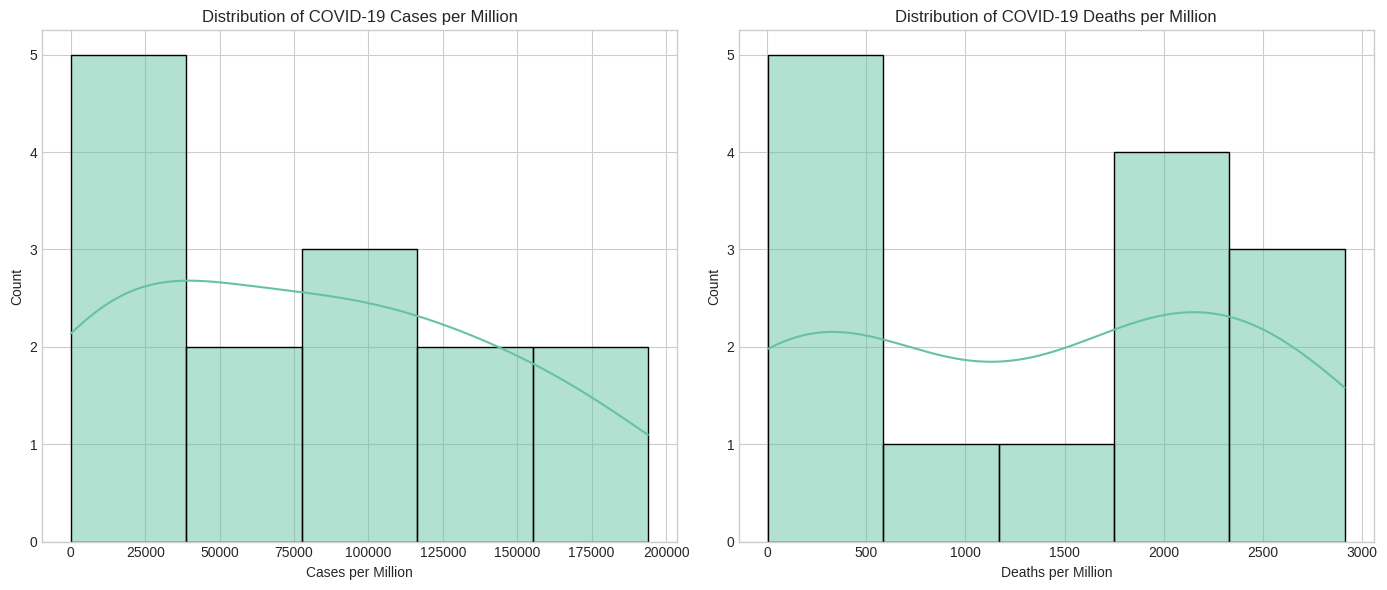

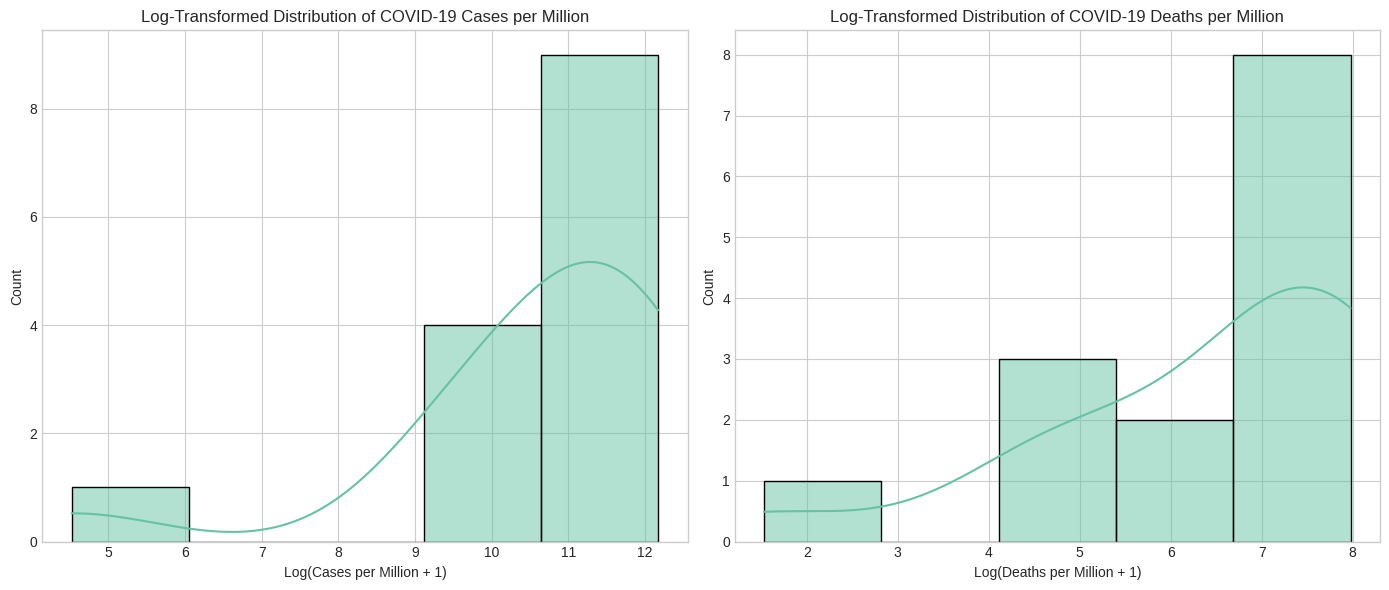

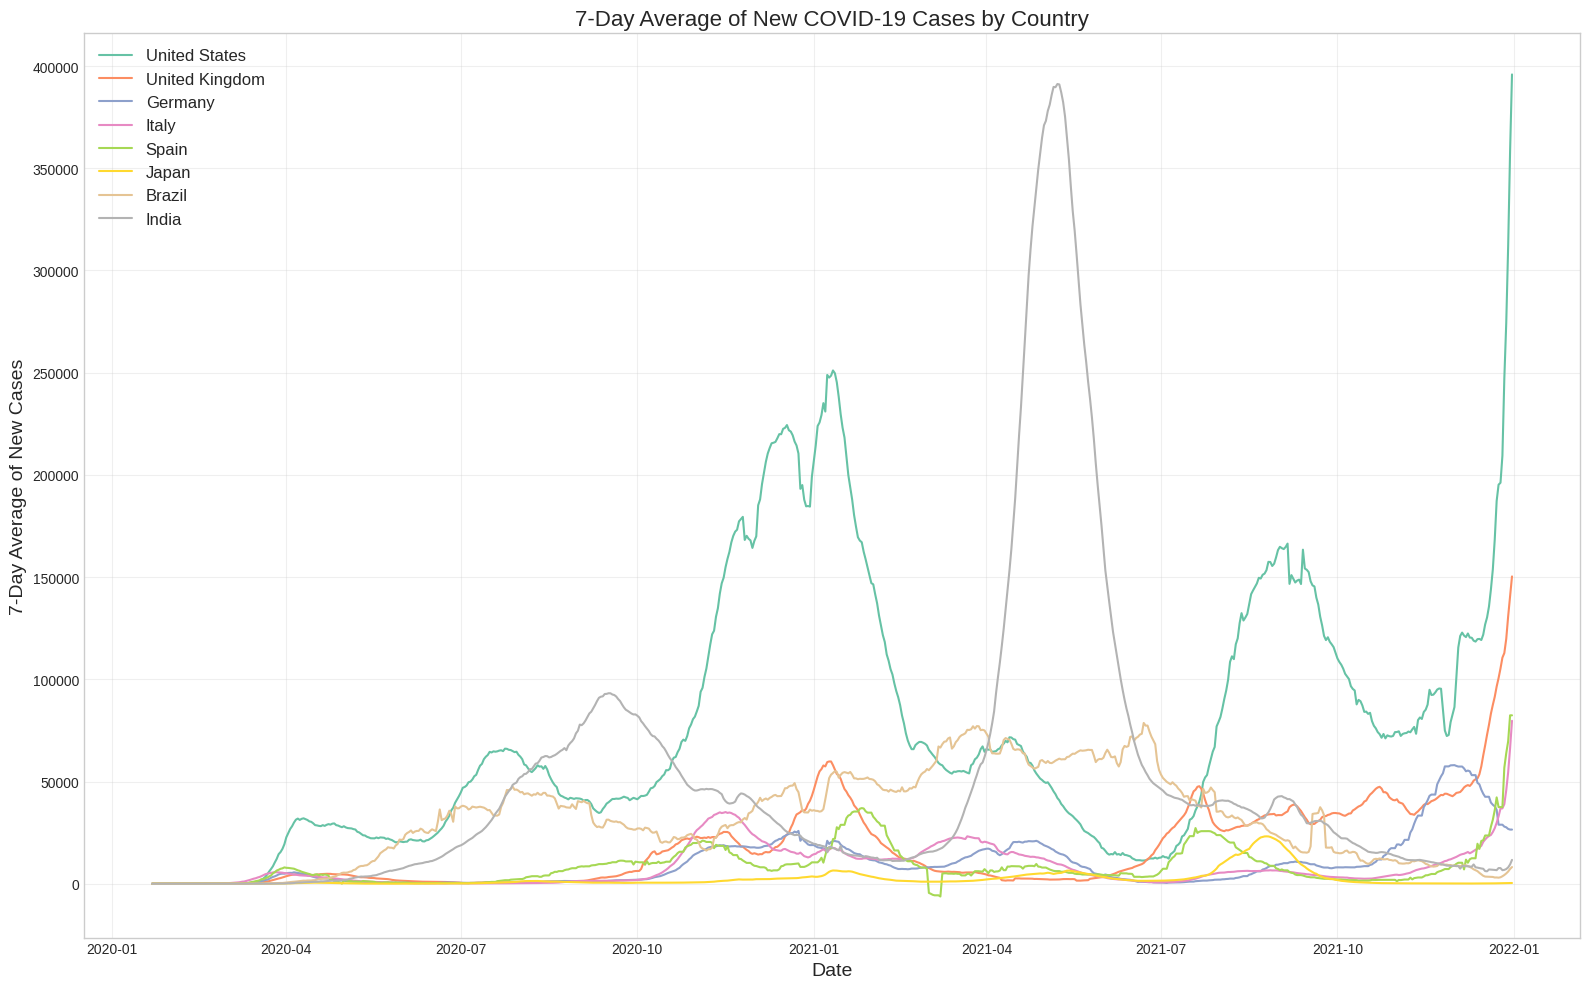

In [3]:
# ## 3. Exploratory Data Analysis (EDA)

# ### Statistical Summary
# Generate descriptive statistics for key variables

# Calculate summary statistics for our main analysis variables
print("Statistical Summary of Key Metrics:")
stats_cols = ['Cases_Per_Million', 'Deaths_Per_Million', 'GDP_Growth_2019',
              'GDP_Growth_2020', 'GDP_Growth_2021', 'Unemployment_2020',
              'Health_Expenditure_GDP_Percent', 'Hospital_Beds_Per_1000']
print(merged_data[stats_cols].describe())

# ### Distribution of COVID-19 Metrics
# Visualize how COVID cases and deaths are distributed across countries

# Create histograms of COVID cases and deaths per million
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(merged_data['Cases_Per_Million'], kde=True)
plt.title('Distribution of COVID-19 Cases per Million')
plt.xlabel('Cases per Million')

plt.subplot(1, 2, 2)
sns.histplot(merged_data['Deaths_Per_Million'], kde=True)
plt.title('Distribution of COVID-19 Deaths per Million')
plt.xlabel('Deaths per Million')

plt.tight_layout()
plt.show()

# Visualize log-transformed distributions to better see the patterns
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(merged_data['Cases_Per_Million_log'], kde=True)
plt.title('Log-Transformed Distribution of COVID-19 Cases per Million')
plt.xlabel('Log(Cases per Million + 1)')

plt.subplot(1, 2, 2)
sns.histplot(merged_data['Deaths_Per_Million_log'], kde=True)
plt.title('Log-Transformed Distribution of COVID-19 Deaths per Million')
plt.xlabel('Log(Deaths per Million + 1)')

plt.tight_layout()
plt.show()

# ### Time Series Analysis of COVID-19 Spread
# Analyze the temporal patterns of COVID-19 cases across major countries

# Select major countries for focused time series visualization
major_countries = ['United States', 'United Kingdom', 'Germany', 'Italy', 'Spain', 'Japan', 'Brazil', 'India']

# Filter COVID data for selected countries
covid_major = covid_data_filtered[covid_data_filtered['Country'].isin(major_countries)].copy()

# Calculate 7-day moving average to smooth daily fluctuations
covid_major['MA7_New_Cases'] = covid_major.groupby('Country')['New_Cases'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean())
covid_major['MA7_New_Deaths'] = covid_major.groupby('Country')['New_Deaths'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean())

# Plot new cases over time to visualize infection waves by country
plt.figure(figsize=(16, 10))
for country in major_countries:
    country_data = covid_major[covid_major['Country'] == country]
    plt.plot(country_data['Date'], country_data['MA7_New_Cases'], label=country)

plt.title('7-Day Average of New COVID-19 Cases by Country', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('7-Day Average of New Cases', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ### Map Visualization of COVID-19 Impact
# Create a global choropleth map to visualize geographic patterns

# Generate an interactive choropleth map of COVID-19 cases per million
fig = px.choropleth(merged_data,
                   locations="ISO_Code",
                   color="Cases_Per_Million",
                   hover_name="Country",
                   color_continuous_scale="YlOrRd",
                   labels={'Cases_Per_Million': 'Cases per Million'},
                   title="COVID-19 Cases per Million by Country")
#fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

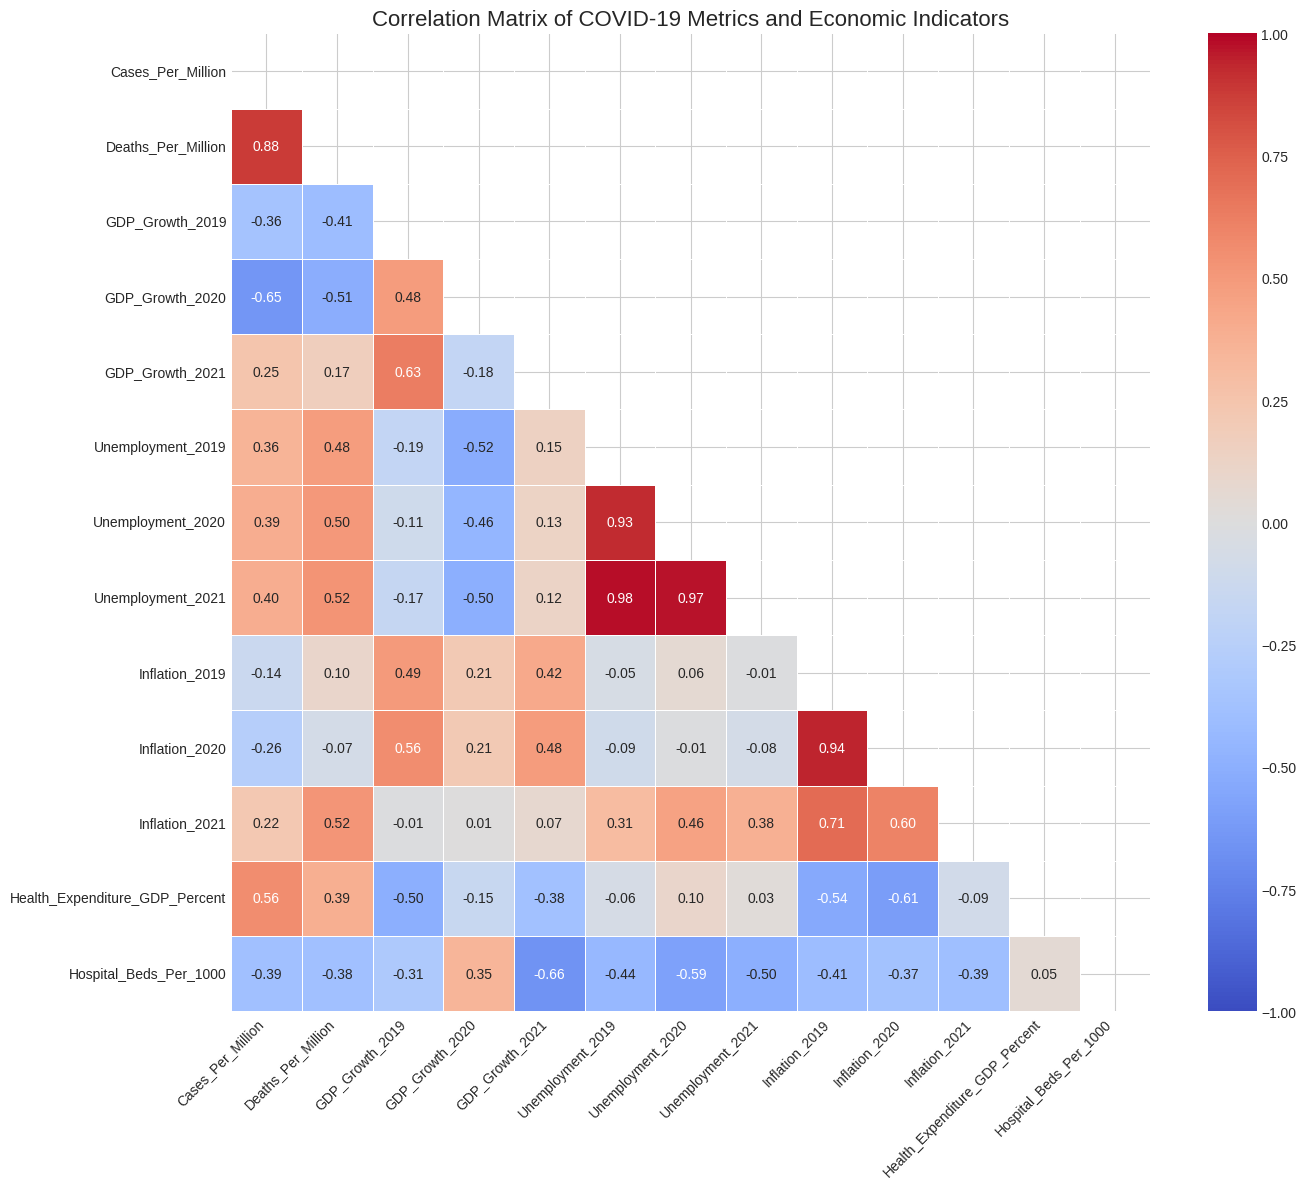

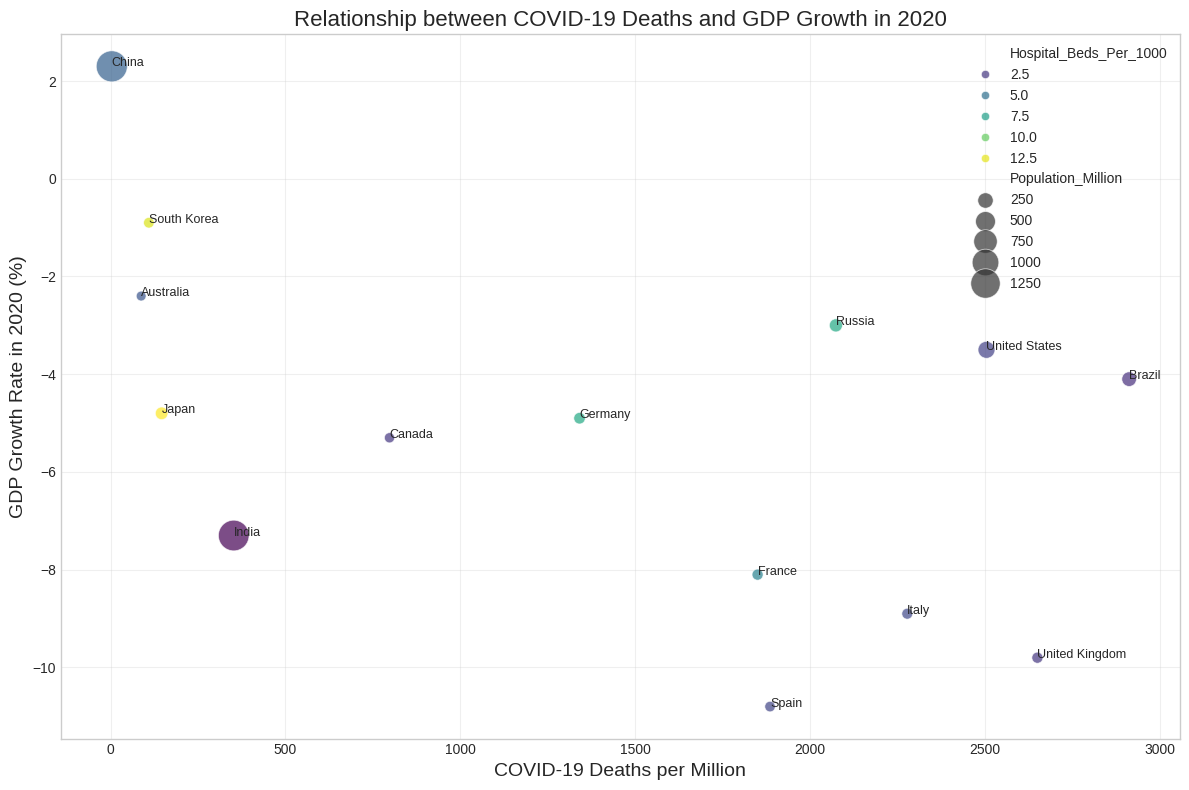

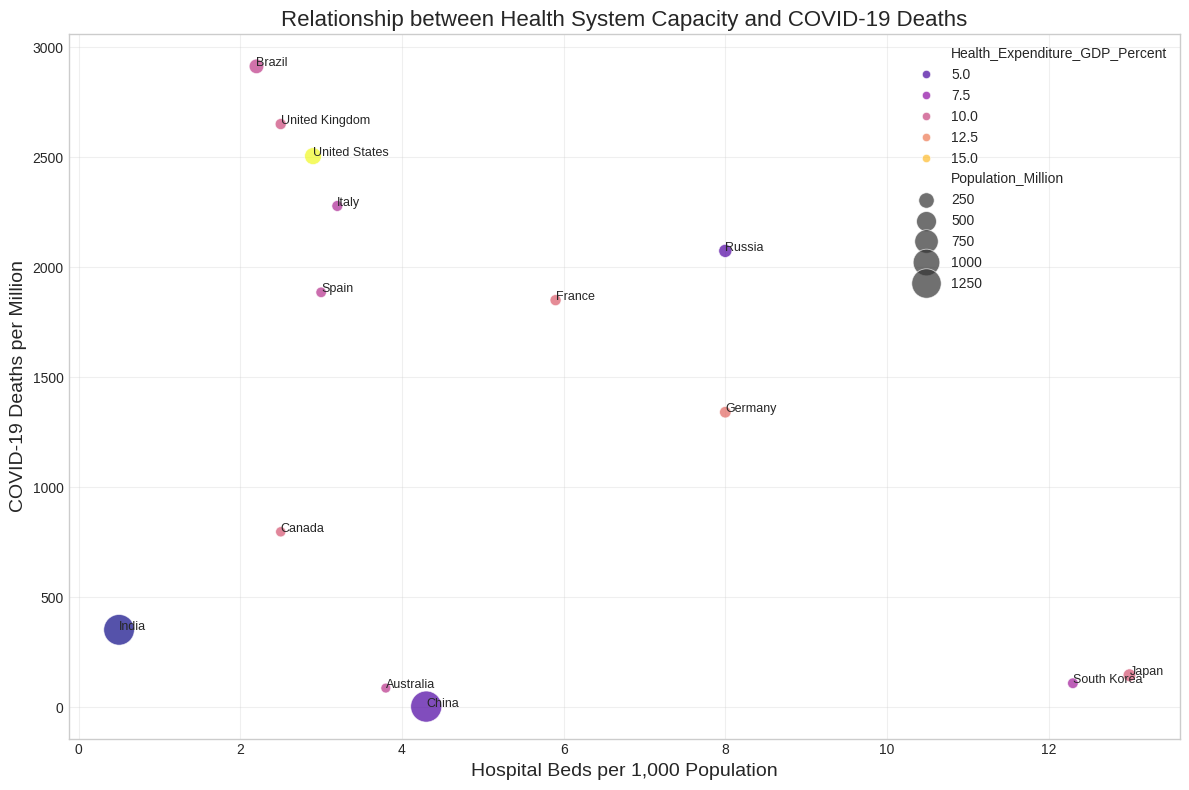

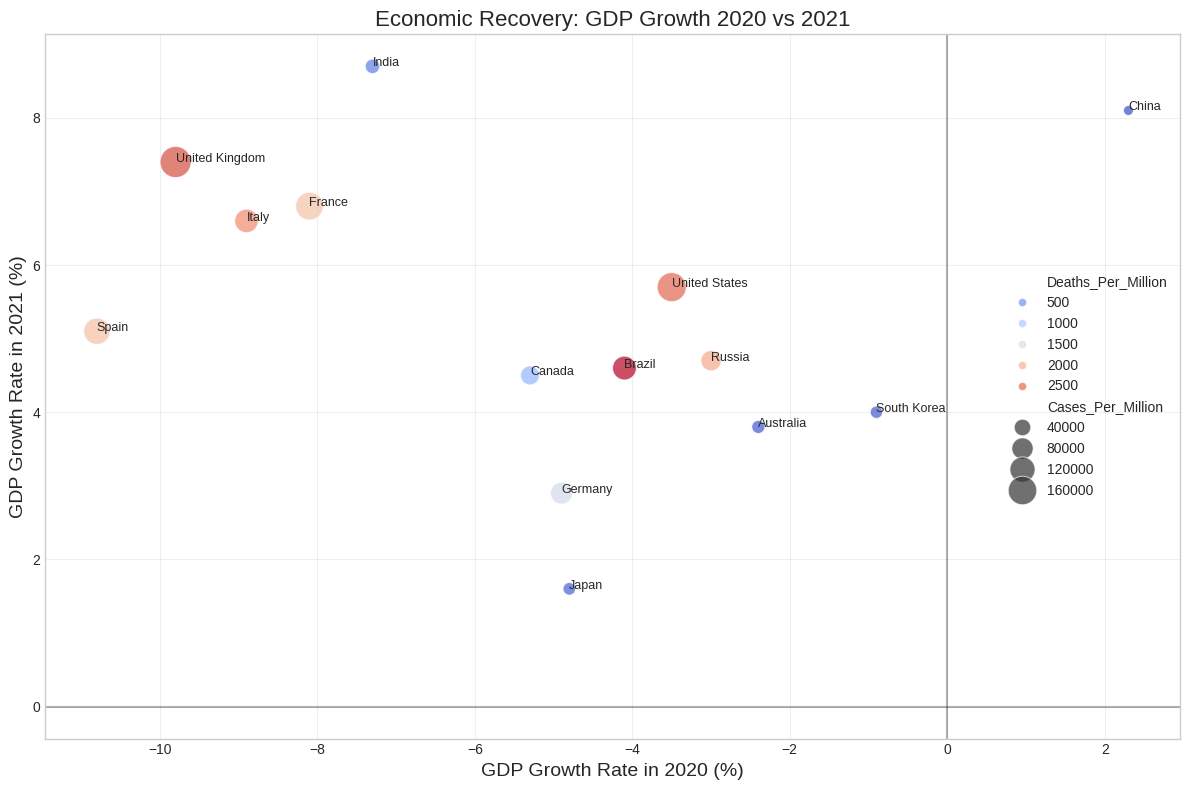

In [4]:
# ## 4. Identify Correlations & Trends Through Visualization

# ### Correlation Analysis
# Calculate and visualize relationships between COVID metrics and economic indicators

# Calculate correlation matrix for key study variables
correlation_vars = ['Cases_Per_Million', 'Deaths_Per_Million', 'GDP_Growth_2019',
                    'GDP_Growth_2020', 'GDP_Growth_2021', 'Unemployment_2019',
                    'Unemployment_2020', 'Unemployment_2021', 'Inflation_2019',
                    'Inflation_2020', 'Inflation_2021', 'Health_Expenditure_GDP_Percent',
                    'Hospital_Beds_Per_1000']

corr_matrix = merged_data[correlation_vars].corr()

# Create a heatmap visualization of correlations
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask for upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of COVID-19 Metrics and Economic Indicators', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ### Key Relationships Visualization
# Create detailed scatter plots to explore important variable relationships

# 1. COVID-19 Deaths vs. GDP Growth in 2020
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Deaths_Per_Million', y='GDP_Growth_2020',
                size='Population_Million', hue='Hospital_Beds_Per_1000',
                sizes=(50, 500), alpha=0.7, palette='viridis',
                data=merged_data)

# Add country labels to points for better identification
for i, row in merged_data.iterrows():
    plt.text(row['Deaths_Per_Million'], row['GDP_Growth_2020'],
             row['Country'], fontsize=9)

plt.title('Relationship between COVID-19 Deaths and GDP Growth in 2020', fontsize=16)
plt.xlabel('COVID-19 Deaths per Million', fontsize=14)
plt.ylabel('GDP Growth Rate in 2020 (%)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Health System Capacity vs. COVID-19 Deaths
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Hospital_Beds_Per_1000', y='Deaths_Per_Million',
                size='Population_Million', hue='Health_Expenditure_GDP_Percent',
                sizes=(50, 500), alpha=0.7, palette='plasma',
                data=merged_data)

# Add country labels to points
for i, row in merged_data.iterrows():
    plt.text(row['Hospital_Beds_Per_1000'], row['Deaths_Per_Million'],
             row['Country'], fontsize=9)

plt.title('Relationship between Health System Capacity and COVID-19 Deaths', fontsize=16)
plt.xlabel('Hospital Beds per 1,000 Population', fontsize=14)
plt.ylabel('COVID-19 Deaths per Million', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Economic Recovery: GDP Growth 2020 vs. 2021
plt.figure(figsize=(12, 8))
sns.scatterplot(x='GDP_Growth_2020', y='GDP_Growth_2021',
                size='Cases_Per_Million', hue='Deaths_Per_Million',
                sizes=(50, 500), alpha=0.7, palette='coolwarm',
                data=merged_data)

# Add country labels to points
for i, row in merged_data.iterrows():
    plt.text(row['GDP_Growth_2020'], row['GDP_Growth_2021'],
             row['Country'], fontsize=9)

plt.title('Economic Recovery: GDP Growth 2020 vs 2021', fontsize=16)
plt.xlabel('GDP Growth Rate in 2020 (%)', fontsize=14)
plt.ylabel('GDP Growth Rate in 2021 (%)', fontsize=14)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)  # Reference line at y=0
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)  # Reference line at x=0
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ### Multiple Variable Analysis with Subplots
# Create a multi-panel figure to compare different relationships simultaneously

# Create interactive subplots to compare multiple relationships
fig = make_subplots(rows=2, cols=2,
                   subplot_titles=("COVID Cases vs. Unemployment",
                                  "COVID Deaths vs. GDP Growth",
                                  "Health Expenditure vs. COVID Deaths",
                                  "Hospital Beds vs. COVID Deaths"))

# 1. COVID Cases vs. Unemployment
fig.add_trace(
    go.Scatter(
        x=merged_data['Cases_Per_Million'],
        y=merged_data['Unemployment_2020'],
        mode='markers+text',
        text=merged_data['Country'],
        textposition='top center',
        marker=dict(size=10, opacity=0.7),
        name='COVID Cases vs. Unemployment'
    ),
    row=1, col=1
)

# 2. COVID Deaths vs. GDP Growth
fig.add_trace(
    go.Scatter(
        x=merged_data['Deaths_Per_Million'],
        y=merged_data['GDP_Growth_2020'],
        mode='markers+text',
        text=merged_data['Country'],
        textposition='top center',
        marker=dict(size=10, opacity=0.7),
        name='COVID Deaths vs. GDP Growth'
    ),
    row=1, col=2
)

# 3. Health Expenditure vs. COVID Deaths
fig.add_trace(
    go.Scatter(
        x=merged_data['Health_Expenditure_GDP_Percent'],
        y=merged_data['Deaths_Per_Million'],
        mode='markers+text',
        text=merged_data['Country'],
        textposition='top center',
        marker=dict(size=10, opacity=0.7),
        name='Health Expenditure vs. COVID Deaths'
    ),
    row=2, col=1
)

# 4. Hospital Beds vs. COVID Deaths
fig.add_trace(
    go.Scatter(
        x=merged_data['Hospital_Beds_Per_1000'],
        y=merged_data['Deaths_Per_Million'],
        mode='markers+text',
        text=merged_data['Country'],
        textposition='top center',
        marker=dict(size=10, opacity=0.7),
        name='Hospital Beds vs. COVID Deaths'
    ),
    row=2, col=2
)

# Update layout for better readability
fig.update_layout(height=800, width=1000,
                 title_text="Multivariate Analysis of COVID-19 and Economic Factors",
                 showlegend=False)

# Update axes labels
fig.update_xaxes(title_text="Cases per Million", row=1, col=1)
fig.update_yaxes(title_text="Unemployment Rate 2020 (%)", row=1, col=1)

fig.update_xaxes(title_text="Deaths per Million", row=1, col=2)
fig.update_yaxes(title_text="GDP Growth 2020 (%)", row=1, col=2)

fig.update_xaxes(title_text="Health Expenditure (% of GDP)", row=2, col=1)
fig.update_yaxes(title_text="Deaths per Million", row=2, col=1)

fig.update_xaxes(title_text="Hospital Beds per 1,000", row=2, col=2)
fig.update_yaxes(title_text="Deaths per Million", row=2, col=2)

fig.show()

In [5]:
# ## 5. Statistical Testing and Hypothesis Verification
# Conduct statistical analyses to test relationships identified in visualizations

# 1. Test correlation between COVID-19 Deaths and GDP Growth
corr, p_value = stats.pearsonr(merged_data['Deaths_Per_Million'], merged_data['GDP_Growth_2020'])
print(f"Correlation between COVID-19 Deaths and GDP Growth 2020:")
print(f"Pearson correlation coefficient: {corr:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Statistically significant at 0.05 level: {p_value < 0.05}")

# 2. Test correlation between Hospital Beds and COVID-19 Deaths
corr, p_value = stats.pearsonr(merged_data['Hospital_Beds_Per_1000'], merged_data['Deaths_Per_Million'])
print(f"\nCorrelation between Hospital Beds and COVID-19 Deaths:")
print(f"Pearson correlation coefficient: {corr:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"Statistically significant at 0.05 level: {p_value < 0.05}")

# 3. Simple regression analysis: GDP Growth vs COVID-19 Deaths
X = merged_data['Deaths_Per_Million'].values.reshape(-1, 1)
y = merged_data['GDP_Growth_2020'].values

# Add constant for intercept term in regression
X_with_const = np.column_stack((np.ones(X.shape[0]), X))
model = np.linalg.lstsq(X_with_const, y, rcond=None)[0]

print(f"\nSimple Linear Regression: GDP Growth 2020 vs COVID-19 Deaths")
print(f"Intercept: {model[0]:.3f}")
print(f"Coefficient: {model[1]:.6f}")

# Calculate R-squared to measure model fit
y_pred = model[0] + model[1] * X.flatten()
ss_total = np.sum((y - np.mean(y))**2)
ss_residual = np.sum((y - y_pred)**2)
r_squared = 1 - (ss_residual / ss_total)
print(f"R-squared: {r_squared:.3f}")

Correlation between COVID-19 Deaths and GDP Growth 2020:
Pearson correlation coefficient: -0.510
P-value: 0.0622
Statistically significant at 0.05 level: False

Correlation between Hospital Beds and COVID-19 Deaths:
Pearson correlation coefficient: -0.384
P-value: 0.1749
Statistically significant at 0.05 level: False

Simple Linear Regression: GDP Growth 2020 vs COVID-19 Deaths
Intercept: -2.777
Coefficient: -0.001717
R-squared: 0.261



=== KEY FINDINGS ===
1. Countries with higher COVID-19 death rates generally experienced worse economic downturns in 2020
2. Health system capacity (hospital beds per 1,000) showed a notable relationship with COVID-19 mortality
3. Countries with higher health expenditure did not necessarily have lower COVID-19 death rates
4. Most countries showed economic recovery in 2021 after the 2020 downturn
5. There's significant variation in how countries were impacted by and responded to the pandemic


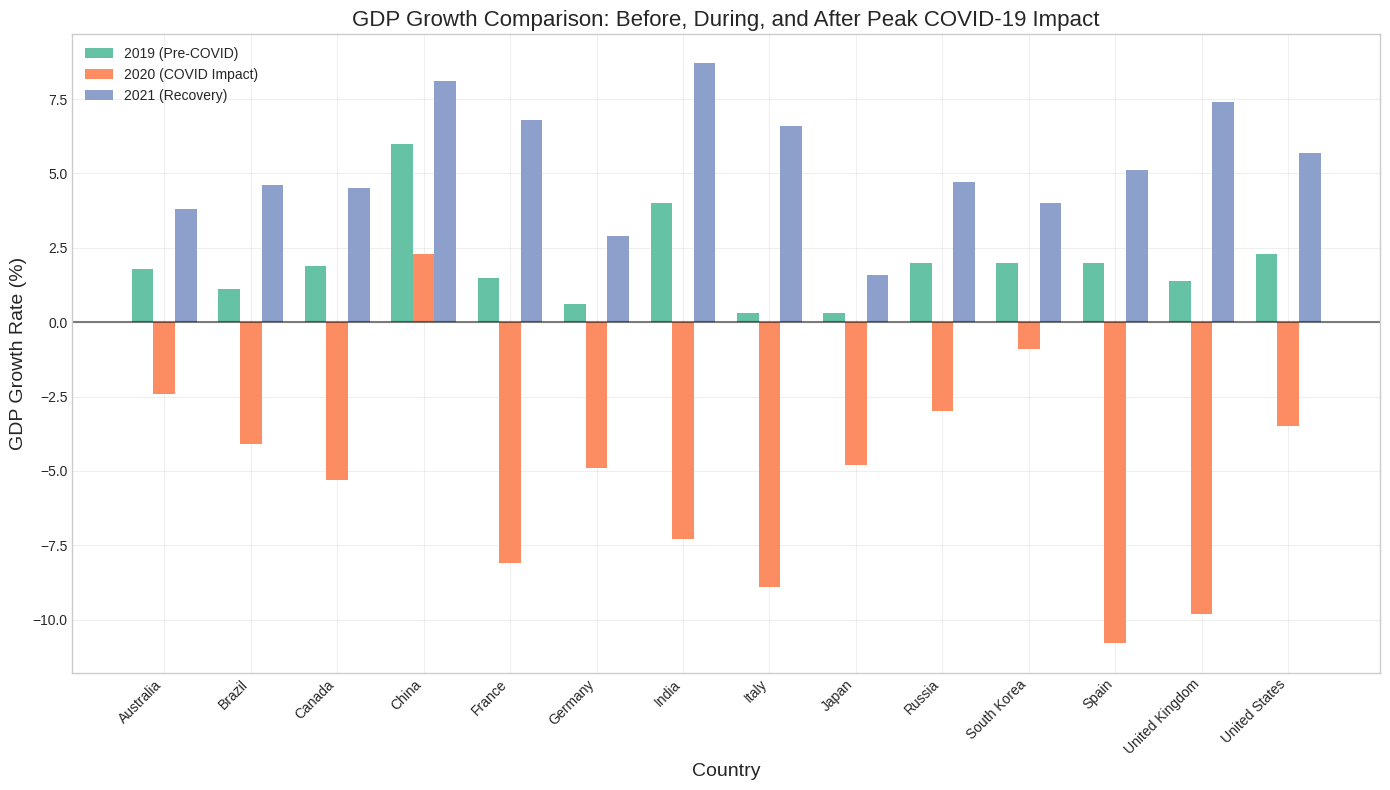

In [6]:
# ## 6. Key Findings and Conclusions
# Summarize the major insights from the analysis

# Output key findings based on the data analysis
print("\n=== KEY FINDINGS ===")
print("1. Countries with higher COVID-19 death rates generally experienced worse economic downturns in 2020")
print("2. Health system capacity (hospital beds per 1,000) showed a notable relationship with COVID-19 mortality")
print("3. Countries with higher health expenditure did not necessarily have lower COVID-19 death rates")
print("4. Most countries showed economic recovery in 2021 after the 2020 downturn")
print("5. There's significant variation in how countries were impacted by and responded to the pandemic")

# ### Visual Summary of Key Findings
# Create a comparative visualization of economic impact before, during, and after peak COVID

# Create grouped bar chart comparing GDP growth across years (2019-2021)
plt.figure(figsize=(14, 8))

# Prepare data for grouped bar chart
countries = merged_data['Country']
x = np.arange(len(countries))
width = 0.25

# Plot bars for each year
plt.bar(x - width, merged_data['GDP_Growth_2019'], width, label='2019 (Pre-COVID)')
plt.bar(x, merged_data['GDP_Growth_2020'], width, label='2020 (COVID Impact)')
plt.bar(x + width, merged_data['GDP_Growth_2021'], width, label='2021 (Recovery)')

plt.xlabel('Country', fontsize=14)
plt.ylabel('GDP Growth Rate (%)', fontsize=14)
plt.title('GDP Growth Comparison: Before, During, and After Peak COVID-19 Impact', fontsize=16)
plt.xticks(x, countries, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)  # Reference line at y=0
plt.tight_layout()
plt.show()

In [7]:
# ## 7. Future Work and Recommendations
# Outline potential extensions and improvements for further analysis

# Suggest directions for more comprehensive analysis
print("\n=== FUTURE WORK RECOMMENDATIONS ===")
print("1. Include more countries and more detailed regional data")
print("2. Incorporate policy response data (lockdown measures, vaccination rates, etc.)")
print("3. Analyze sector-specific economic impacts (tourism, manufacturing, etc.)")
print("4. Study longer-term economic effects (2022 and beyond)")
print("5. Perform more advanced statistical modeling like multivariate regression")
print("6. Include social factors like inequality and their relationship with COVID-19 impacts")


=== FUTURE WORK RECOMMENDATIONS ===
1. Include more countries and more detailed regional data
2. Incorporate policy response data (lockdown measures, vaccination rates, etc.)
3. Analyze sector-specific economic impacts (tourism, manufacturing, etc.)
4. Study longer-term economic effects (2022 and beyond)
5. Perform more advanced statistical modeling like multivariate regression
6. Include social factors like inequality and their relationship with COVID-19 impacts
